# Evaluating Sustainability using EvaluationAgent

| Component | Details |
|-----------|---------|
| **Goal** | Show how to evaluate the sustainability of optimization algorithms by measuring inference time, energy consumption, CO₂ emissions, and quality trade-offs. |
| **Model** | [stable-diffusion-v1-5/stable-diffusion-v1-5](https://huggingface.co/stable-diffusion-v1-5/stable-diffusion-v1-5) |
| **Dataset** | [LAION256](https://huggingface.co/datasets/nannullna/laion_subset) (10-sample subset) |
| **Device** | 1 x T4 (16GB) |
| **Optimization Algorithms** | cacher(deepcache), compiler(torch_compile) |
| **Evaluation Metrics** | `total_time`, `energy_consumed`, `co2_emissions`, `clip_score` |

## Getting Started

To install the required dependencies, you can run the following command:

In [ ]:
%pip install pruna

For more information about how to install Pruna, please refer to the [Installation](https://docs.pruna.ai/en/stable/setup/install.html) page.

## 1. Load the Model

First, we load the model. We use [stable-diffusion-v1-5](https://huggingface.co/stable-diffusion-v1-5/stable-diffusion-v1-5), one of the most widely used text-to-image diffusion models: it is small enough to run on a T4 GPU while still being representative of the compute and energy profile of real image-generation workloads. Feel free to swap in any other diffusion model from Hugging Face.

In [ ]:
import torch
from diffusers import AutoPipelineForText2Image

from pruna.engine.pruna_model import PrunaModel

pipe = AutoPipelineForText2Image.from_pretrained(
    "stable-diffusion-v1-5/stable-diffusion-v1-5",
    torch_dtype=torch.float16,
    use_safetensors=True,
)
pipe = pipe.to("cuda")
model = PrunaModel(pipe)
pipe.set_progress_bar_config(disable=True)

# Shared generation parameters, applied to every configuration so results are comparable
GEN_ARGS = {"num_inference_steps": 25, "guidance_scale": 7.5}

## 2. Define the Evaluation Metrics

`pruna` tracks three sustainability metrics:

- **`total_time`**: wall-clock time to run the benchmark iterations (ms)
- **`energy_consumed`**: total energy drawn during inference (kWh)
- **`co2_emissions`**: estimated CO₂-equivalent emissions based on energy consumed and hardware location (kg)

We also include **`clip_score`**, a quality metric measuring how well generated images match their prompts, so we can check whether efficiency gains come at a quality cost.

We will pass these metrics to the evaluation `Task` as a list of metric instances. For other ways to specify metrics, see the [evaluation documentation](https://docs.pruna.ai/en/stable/docs_pruna/user_manual/evaluate.html).

In [ ]:
from pruna.evaluation.metrics import (
    CO2EmissionsMetric,
    EnergyConsumedMetric,
    TorchMetricWrapper,
    TotalTimeMetric,
)

request = [
    TotalTimeMetric(n_iterations=10, n_warmup_iterations=3),
    EnergyConsumedMetric(n_iterations=10, n_warmup_iterations=3),
    CO2EmissionsMetric(n_iterations=10, n_warmup_iterations=3),
    TorchMetricWrapper("clip_score"),
]

## 3. Create an EvaluationAgent and a Task

Pruna's evaluation process uses a Task to define which metrics to calculate and provide the evaluation data. The EvaluationAgent then takes this Task and handles running the model inference, passing the inputs, ground truth, and predictions to each metric, and collecting the results.

In [ ]:
from pruna.data.pruna_datamodule import PrunaDataModule
from pruna.evaluation.evaluation_agent import EvaluationAgent
from pruna.evaluation.task import Task

datamodule = PrunaDataModule.from_string("LAION256")
datamodule.limit_datasets(10)  # Quality metrics run over these 10 samples. Timing metrics benchmark a single batch
task = Task(request, datamodule)
eval_agent = EvaluationAgent(task)

## 4. Evaluate the Baseline Model

We can evaluate a model by calling the `evaluate` method of the EvaluationAgent.

In [ ]:
model.inference_handler.model_args.update(GEN_ARGS)

base_results = eval_agent.evaluate(model)
for r in base_results:
    print(f"{r.name}: {r.result:.4g}")

## 5. Smash the Model with DeepCache

[DeepCache](https://docs.pruna.ai/en/stable/compression.html#deepcache) is a caching algorithm for diffusion models: it exploits the redundancy between consecutive denoising steps by caching intermediate UNet feature maps and reusing them in later steps, skipping part of the computation. Since the GPU does less work per image, we expect inference time (and with it energy consumption and CO₂ emissions) to drop, possibly at a small cost in image quality.

In [ ]:
import copy

from pruna import smash
from pruna.config.smash_config import SmashConfig
from pruna.engine.utils import safe_memory_cleanup

smash_config = SmashConfig()
smash_config.add(dict(deepcache=True))

pipe = pipe.to("cpu")
safe_memory_cleanup()

copy_pipe = copy.deepcopy(pipe).to("cuda")
smashed_pipe = smash(copy_pipe, smash_config)
smashed_pipe.set_progress_bar_config(disable=True)
smashed_pipe.inference_handler.model_args.update(GEN_ARGS)

## 6. Evaluate the Smashed Model (DeepCache)

We now evaluate the smashed model by calling evaluate again.

In [ ]:
smashed_results = eval_agent.evaluate(smashed_pipe)
for r in smashed_results:
    print(f"{r.name}: {r.result:.4g}")

## 7. Analyze Baseline vs. DeepCache

With both configurations evaluated on the same task, we can now compare them side by side. For time, energy, and CO₂ a negative change is an improvement. For CLIP score, higher is better.

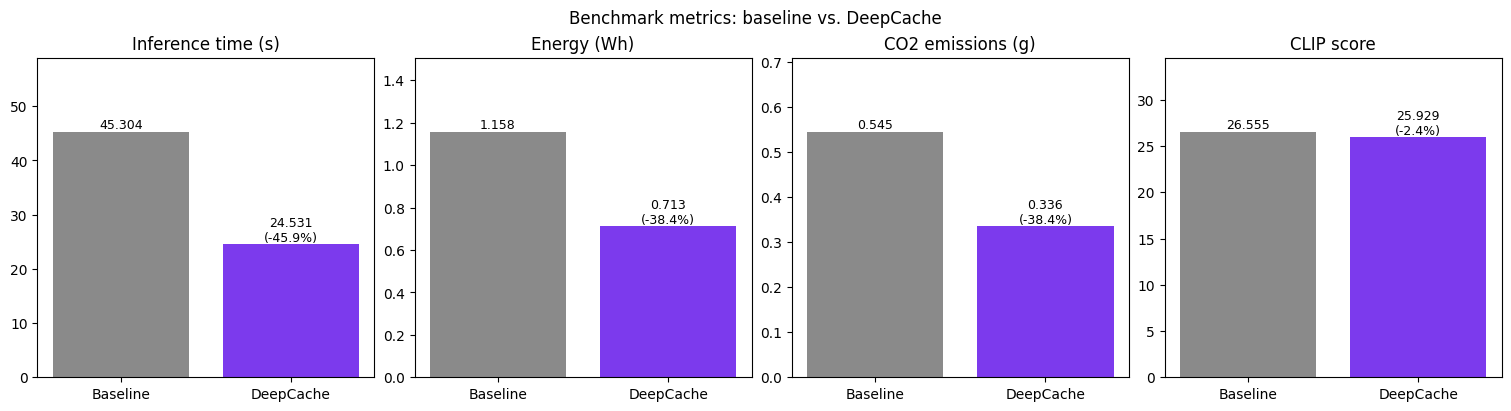

In [ ]:
import matplotlib.pyplot as plt

base = {r.name: r.result for r in base_results}
smashed = {r.name: r.result for r in smashed_results}

metrics = {
    "Inference time (s)": ("total_time", 1e-3),   # ms -> s
    "Energy (Wh)": ("energy_consumed", 1e3),      # kWh -> Wh
    "CO2 emissions (g)": ("co2_emissions", 1e3),  # kg -> g
    "CLIP score": ("clip_score", 1),
}

fig, axes = plt.subplots(1, 4, figsize=(15, 4), layout="constrained")

for ax, (label, (key, scale)) in zip(axes, metrics.items()):
    values = [base[key] * scale, smashed[key] * scale]
    bars = ax.bar(["Baseline", "DeepCache"], values, color=["#8a8a8a", "#7c3aed"])
    change = (values[1] / values[0] - 1) * 100
    ax.bar_label(bars, labels=[f"{values[0]:.3f}", f"{values[1]:.3f}\n({change:+.1f}%)"], fontsize=9)
    ax.set_ylim(0, max(values) * 1.3)
    ax.set_title(label)

fig.suptitle("Benchmark metrics: baseline vs. DeepCache")
plt.show()

DeepCache roughly halves inference time (-46%) and cuts energy consumption and CO₂ emissions by about 38%, at the cost of a 2.4% drop in CLIP score.

## 8. Smash the Model with torch_compile

In contrast to DeepCache, [torch_compile](https://docs.pruna.ai/en/stable/compression.html#torch-compile) does not skip any computation: it compiles the model into optimized GPU kernels, so the exact same work runs faster. The generated images stay essentially identical, so quality is unaffected, but because the savings come purely from better kernel execution, how much time, energy, and CO₂ you save depends on your hardware.

In [ ]:
# Free the DeepCache pipeline before building the next configuration
del smashed_pipe
safe_memory_cleanup()

# Smash with torch.compile (start from a fresh copy of the original pipe)
compile_config = SmashConfig()
compile_config.add(dict(torch_compile=True))

compile_pipe = smash(copy.deepcopy(pipe).to("cuda"), compile_config)
compile_pipe.set_progress_bar_config(disable=True)
compile_pipe.inference_handler.model_args.update(GEN_ARGS)

## 9. Evaluate the Smashed Model (torch_compile)

In [ ]:
compiled_results = eval_agent.evaluate(compile_pipe)
for r in compiled_results:
    print(f"{r.name}: {r.result:.4g}")

## 10. Analyze Baseline vs. DeepCache vs. torch_compile

With all three configurations evaluated on the same task, we can compare them in a single visual.

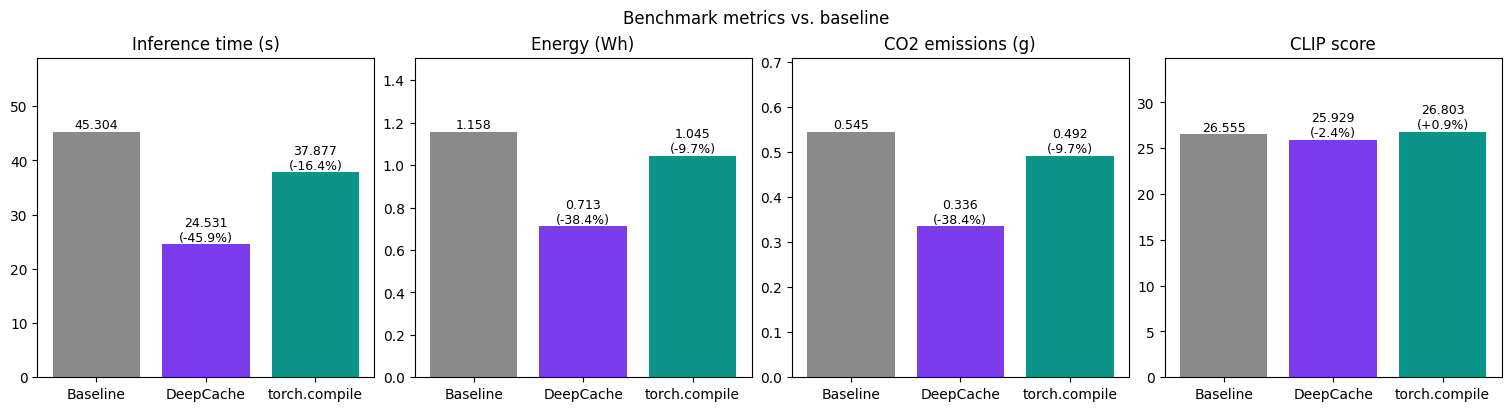

In [ ]:
all_results = {
    "Baseline": base_results,
    "DeepCache": smashed_results,
    "torch.compile": compiled_results,
}
data = {name: {r.name: r.result for r in res} for name, res in all_results.items()}

# Convert to more readable units for small workloads
metrics = {
    "Inference time (s)": ("total_time", 1e-3),   # ms -> s
    "Energy (Wh)": ("energy_consumed", 1e3),      # kWh -> Wh
    "CO2 emissions (g)": ("co2_emissions", 1e3),  # kg -> g
    "CLIP score": ("clip_score", 1),
}

names = list(all_results)
colors = ["#8a8a8a", "#7c3aed", "#0d9488"]

fig, axes = plt.subplots(1, 4, figsize=(15, 4), layout="constrained")

for ax, (label, (key, scale)) in zip(axes, metrics.items()):
    vals = [data[name][key] * scale for name in names]
    bars = ax.bar(names, vals, color=colors)
    labels = [f"{v:.3f}" if i == 0 else f"{v:.3f}\n({(v / vals[0] - 1) * 100:+.1f}%)"
              for i, v in enumerate(vals)]
    ax.bar_label(bars, labels=labels, fontsize=9)
    ax.set_ylim(0, max(vals) * 1.3)
    ax.set_title(label)

fig.suptitle("Benchmark metrics vs. baseline")
plt.show()

DeepCache delivers the largest savings but with a small quality dip, while torch.compile saves less (16% time, 10% energy/CO₂) yet leaves quality untouched (CLIP score +0.9%).

## Conclusions

All three sustainability metrics move in the same direction: less inference time means less energy consumption and CO₂ emissions. In this workflow, DeepCache cuts inference time by about 46%, and energy and CO₂ by about 38% because baseline power draw (such as RAM and idle GPU power) is consumed regardless of how fast the computation runs. For torch.compile, inference time is cut by 16% while energy and CO₂ are cut by 10%. DeepCache achieves this by skipping redundant UNet computation, while torch.compile runs the same computation with faster kernels, so its gains depend on the hardware.

CLIP score shows a slight drop for DeepCache, hinting at a small quality tradeoff even in this limited run. For another comparison, see the [CMMD evaluation tutorial](./evaluation_agent_cmmd.ipynb).